<a href="https://colab.research.google.com/github/JoaoDomingos2001/TrabalhoGrupoPEMS/blob/main/TrabalhoGrupoPEMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho de Grupo
Este trabalho serve para a cadeira de Python para o Ensino da Matemática no Secundário (PEMS) demonstrar as aplicações do intervalo de confiança.

Docente Responsável:
*  Prof.º Celestino Coelho

Trabalho realizado por:

Grupo nº7

*   João Domingos - nº90121
*   Juliana Gonçalves – nº69062
*   Marco Pereira – nº90527
*   Maria Bernardes - nº91071

## Intervalo de Confiança

**"Inferir a população a partir de uma amostra representativa"**
Não se conhecem parâmetros relativos a uma população, mas sim as estatísticas relativas a uma amostra que se considera representativa.

**Como fazer?**
Estabelecer inferências para a população a partir das informações fornecidas por uma amostra.
Fazer com grau de confiança e uma margem de erro pré-estabelicida.

### Exemplos
- Estimar a percentagem de eleitores portugueses que apoiarão determinado candidato nas próximas eleições presidenciais, a partir de uma sondagem;
- Estimar o valor médio da altura média da população de alunos de uma escola, a partir dos dados de uma turma dessa mesma escola;
- Estimar a nota no Exame de MACS, numa determinada região, a partir de uma amostra de 64 provas.

**Nota:** As distribuições de amostragem das estatísticas (por ex.: médias e desvio padrão amostrais) devem ter um comportamento aproximadamente normal se a dimensão da amostra for suficientemente grande $(n >= 30)$.

Intervalo de confiança para o valor médio 𝜇 de uma variável normal 𝑋, admitindo que se conhece o desvio padrão da variável = $\bar{x} \pm z \times \frac{\sigma}{\sqrt{n}}$

Sendo:
  -  $n$ - dimensão da amostra
  -  $\bar{x}$ - média amostral
  -  σ - desvio padrão variável
  -  $z$ - valor relacionado com o nível de confiança

Intervalo de confiança para o valor médio 𝜇 de uma variável normal 𝑋, admitindo que se desconhece o desvio padrão da variável e que a amostra tem dimensão superior a 30 = $\bar{x} \pm z \times \frac{s}{\sqrt{n}}$

Sendo:
  -  $n$ - dimensão da amostra
  -  $\bar{x}$ - média amostral
  -  $s$ - desvio padrão amostral
  -  $z$ - valor relacionado com o nível de confiança

## Margem de Erro
Erro maximo entre o valor estimado e o valor real;
\
Calcula-se de duas formas:
- Metade da amplitude do intervalo entre os dois limites do intervalo de confiança;
- Quociente entre $ Z \times \frac{\sigma}{\sqrt{n}}$


## Níveis de confiança
Valores de $z$ para os níveis de confiança mais usuais:
\
\begin{array}{|c|c|c|c|}
\hline
\textbf{Nível de confiança} & 90\% & 95\% & 99\% \\
\hline
z & 1,645 & 1,960 & 2,576 \\
\hline
\end{array}

$z$ - É a probabilidade de um determinado intervalo, centrado numa estimativa, conter o verdadeiro parâmetro populacional.
Representa-se por $1 - α$, em que α representa a diferença entre a certeza total (100%) e o nível de confiança


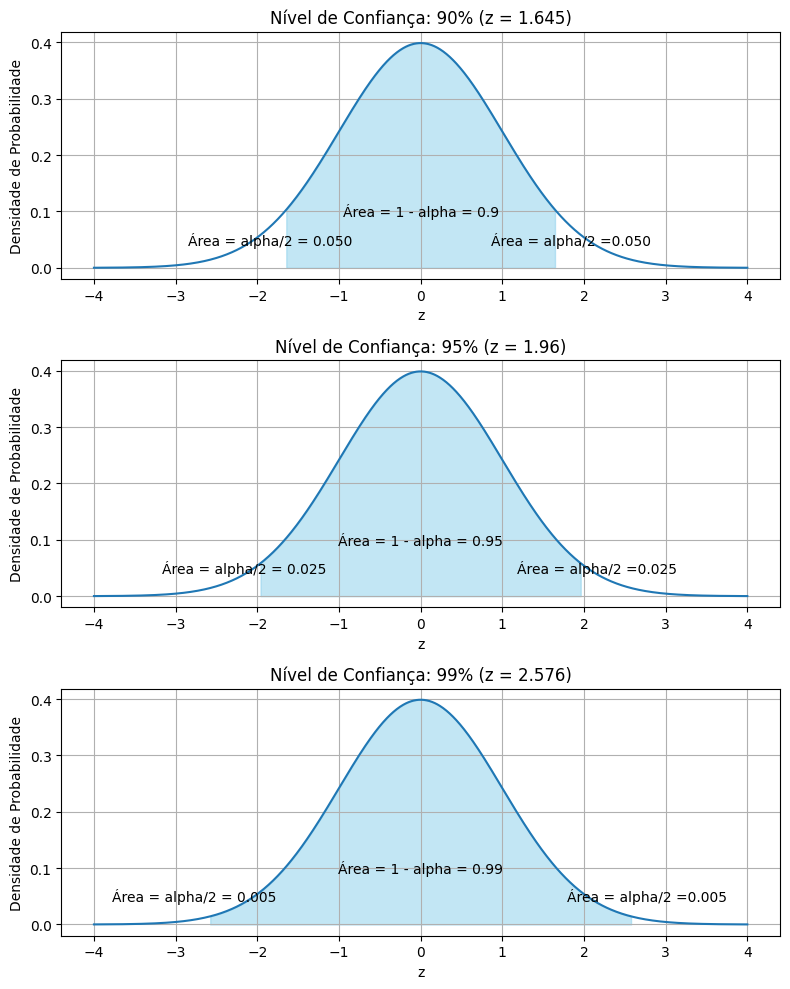

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Generate x values for the normal distribution
x = np.linspace(-4, 4, 1000)

# Define confidence levels and corresponding z-values
confidence_levels = [0.90, 0.95, 0.99]
z_values = [1.645, 1.960, 2.576]

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for i, (confidence, z) in enumerate(zip(confidence_levels, z_values)):
    # Calculate alpha
    alpha = 1 - confidence

    # Plot the standard normal distribution
    axes[i].plot(x, norm.pdf(x), label='Normal Padrão')

    # Shade the confidence interval
    x_fill = np.linspace(-z, z, 1000)
    axes[i].fill_between(x_fill, norm.pdf(x_fill), color='skyblue', alpha=0.5)

    # Add text for confidence level
    axes[i].text(0, 0.1, f"Área = 1 - alpha = {confidence}", ha='center', va='center', fontsize=10)
    axes[i].text(z + 0.2, 0.05, f"Área = alpha/2 ={alpha/2:.3f}", ha='center', va='center', fontsize=10)
    axes[i].text(-z - 0.2, 0.05, f"Área = alpha/2 = {alpha/2:.3f}", ha='center', va='center', fontsize=10)


    # Set subplot title
    axes[i].set_title(f"Nível de Confiança: {confidence*100:.0f}% (z = {z})")

    # Set axis labels
    axes[i].set_xlabel('z')
    axes[i].set_ylabel('Densidade de Probabilidade')


    axes[i].grid(True)


# Adjust layout and show the plot
plt.tight_layout()
plt.show()


#### Exercício: Valor médio de Calorias ingeridas

Considera uma amostra aleatória de 50 almoços servidos numa cantina de uma escola. com a média de calorias ingeridas de 800 e com desvio padrão 100.

Constrói um intervalo de confiança de 95% para o valor médio de calorias ingeridas ao almoçp, calcula a sua margem de erro e interpreta os resultados obtidos.
\
\
*Intervalo de confiança: Intervalo em relação ao qual temos uma certa confiança que contenha o valor do parâmetro. Essa confiança designa-se por grau ou nível de confiança.*

In [ ]:
#nº de calorias ingeridas ao almoço
n_dim = 50 #dimensão da amostra
nivel_confianca = 0.95 #Nível de confiança
media = 800 #média da amostra
desvio_padrao = 100 #desvio padrão da amostra
var_estudo = "Calorias ingeridas" #variável de estudo

def z_value(nivel_confianca):
    if nivel_confianca == 0.90:
        return 1.645
    elif nivel_confianca == 0.95:
        return 1.960
    elif nivel_confianca == 0.99:
        return 2.576
    else:
        return print("Erro!")

def intervalo_confianca(n_dim, nivel_confianca, media, desvio_padrao, var_estudo):
    z = z_value(nivel_confianca)

    #Calcular os limites
    lim_inferior = media - (z * (desvio_padrao / (n_dim ** 0.5)))
    lim_superior = media + (z * (desvio_padrao / (n_dim ** 0.5)))

    print("Com uma confiança de ", nivel_confianca * 100, "%, estima-se que o valor médio ", var_estudo, " esteja entre ", f"{lim_inferior:.3f}", "e", f"{lim_superior:.3f}", ".")

    #Devolve os limites do intervalo de confiança
    return lim_inferior, lim_superior


Lim_inf, Lim_sup = intervalo_confianca(n_dim, nivel_confianca, media, desvio_padrao, var_estudo)

#Demonstração de duas maneiras de calcular a margem de erro
def margem_erro(n_dim, nivel_confianca, media, desvio_padrao):
    z = z_value(nivel_confianca)
    margem_erro = z * (desvio_padrao / (n_dim ** 0.5))
    #print("A margem de erro é de ", f"{margem_erro:.3f}", ".")
    print("Para um intervalo de confiança de ", nivel_confianca * 100,"%, o nº de ", var_estudo," difere mais ou menos ", f"{margem_erro:.3f}", " do verdadeiro valor.")
    return margem_erro

margem = margem_erro(n_dim, nivel_confianca, media, desvio_padrao)

def margem_erro_alternativo(Lim_inf, Lim_sup):
    margem_erro_alt = (Lim_sup - Lim_inf) / 2
    print("A margem de erro calculada de forma alternativa é de ", f"{margem_erro_alt:.3f}", ".")
    return margem_erro_alt

margem_alt = margem_erro_alternativo(Lim_inf, Lim_sup)


Com uma confiança de  95.0 %, estima-se que o valor médio  Calorias ingeridas  esteja entre  772.281 e 827.719 .
Para um intervalo de confiança de  95.0 %, o nº de  Calorias ingeridas  difere mais ou menos  27.719  do verdadeiro valor.
A margem de erro calculada de forma alternativa é de  27.719 .


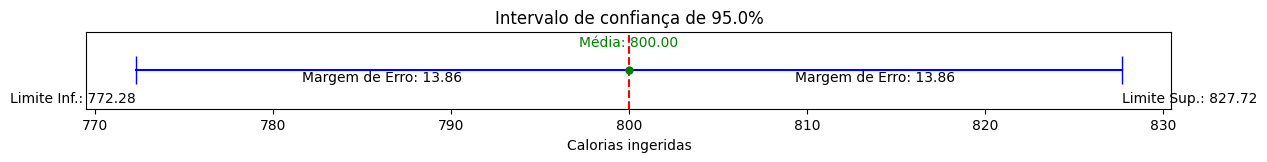

In [ ]:
def grafico(Lim_inf, Lim_sup, media, margem, var_estudo, nivel_confianca):
  import matplotlib.pyplot as plt

  #Criação do Plot
  plt.figure(figsize=(14, 1)) # Adjust figure size for a line
  plt.plot([Lim_inf, Lim_sup], [0, 0], marker='|', markersize=20, linestyle='-', color='blue') # Usar para criar a linha Horizontal
  plt.axvline(x=media, color='red', linestyle='--') # Adicionar uma linha para a identificar a média
  plt.plot(media,0, marker='o', markersize=5, color = 'green') #Adicionar um ponto para identificar a média


  #Adicionar as legendas para os limites do intervalo de confiança
  plt.text(Lim_inf, -0.03, f'Limite Inf.: {Lim_inf:.2f}', ha='right', va='top') #Limite Inferior
  plt.text(Lim_sup, -0.03, f'Limite Sup.: {Lim_sup:.2f}', ha='left', va='top') #Limite Superior

  #Adicionar a legenda para a média
  plt.text(media, 0.03, f'Média: {media:.2f}', ha='center', va='bottom', color='green')

  #Adicionar a legenda para a margem de erro
  margem_erro_display = margem / 2
  plt.text(media + margem_erro_display, 0.00001, f'Margem de Erro: {margem_erro_display:.2f}', ha='center', va='top')
  plt.text(media - margem_erro_display, 0.00001, f'Margem de Erro: {margem_erro_display:.2f}', ha='center', va='top')

  plt.title(f'Intervalo de confiança de {nivel_confianca* 100 }%') # Title of the graph
  plt.xlabel(var_estudo) # x axis label
  plt.yticks([]) # Remove y-axis ticks
  plt.grid(False) #Remove grid from the plot
  plt.show()

  return

grafico(Lim_inf, Lim_sup, media, margem, var_estudo, nivel_confianca)

##### Explicação

Resumindo, a partir de 100 amostras com a mesma dimensão em todas as amostras e com um nível de confiança de 95% espera-se que:
- 95 dos 100 intervalos **contêm** o valor real da média
- E, 5 dos 100 intervalos **não contêm** o valor real da média


#### Exercício: Aluguer de bicicletas

A Paula aluga bicicletas elétricas. A tabela apresenta os dados relativosà variável: "Número de alugueres efetuados pela Paula em cada semana", numa amostra aleatória de 36 semanas:
\
\begin{array}{|c|c|}
\hline
\textbf{N.º de alugueres} & \textbf{N.º de semanas} \\
\hline
0 & 5 \\
\hline
1 & 6 \\
\hline
3 & 16 \\
\hline
4 & 9 \\
\hline
\end{array}
\
Constrói um intervalo de confiança a 90% para estimar o valor médio da variável.
Na resolução do exercício apresenta os valores do desvio padrão amostral e dos extremos do intervalos de confiança com arredondamentos ás décimas.

##### Recorda:
- Média:
$\bar{x} = \frac{x1+x2+x3+x4+x5+...+xn}{n}$, em que $n$ representa a dimensão da amostra.

- Desvio padrão amostral:
$$s = \sqrt{\frac{(x_1 - \bar{x})^2 \times n_1 + (x_2 - \bar{x})^2 \times n_2 + (x_3 - \bar{x})^2 \times n_3 + \dots + (x_n - \bar{x})^2 \times n_n}{n - 1}}$$

Ou

$$ s = \sqrt{\frac{\sum_{i=1}^{n} n_i \times (x_i - \bar{x})^2}{n - 1}} \quad $$, onde $n_i$ é a frequência absoluta associada a cada $x_i$

Média:  2.500
Desvio Padrão:  1.404
Com uma confiança de  90.0 %, estima-se que o valor médio  Aluguer de bicicletas  esteja entre  2.115 e 2.885 .
Para um intervalo de confiança de  90.0 %, o nº de  Aluguer de bicicletas  difere mais ou menos  0.385  do verdadeiro valor.


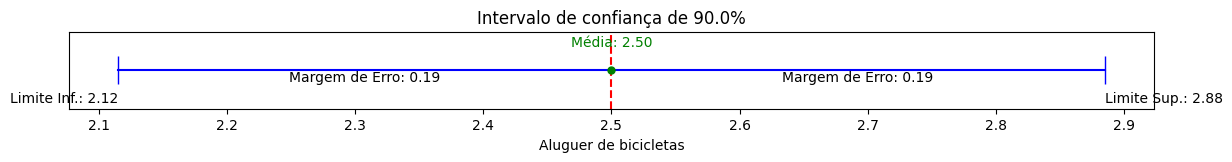

In [ ]:
#Como estamos perante de uma amostra precisamos de calcular a média e o desvio padrão amostral
#Calcular a média
n_aluguer = [0, 1, 3, 4]
n_bicicletas = [5, 6, 16, 9]

for i in range(len(n_aluguer)):
    media = sum(n_aluguer[i] * n_bicicletas[i] for i in range(len(n_aluguer))) / sum(n_bicicletas)

print("Média: ", f"{media:.3f}")

#Calcular o desvio padrão
desvio_padrao = (sum(n_bicicletas[i] * ((n_aluguer[i] - media) ** 2) for i in range(len(n_aluguer))) / (sum(n_bicicletas) - 1))**0.5

print("Desvio Padrão: ", f"{desvio_padrao:.3f}")

n_dim = sum(n_bicicletas) #dimensão da amostra
nivel_confianca = 0.90 #Nível de confiança
var_estudo = "Aluguer de bicicletas" #variável de estudo

Lim_inf_ex, Lim_sup_ex = intervalo_confianca(n_dim, nivel_confianca, media, desvio_padrao, var_estudo)
margem_ex = margem_erro(n_dim, nivel_confianca, media, desvio_padrao)
grafico(Lim_inf_ex, Lim_sup_ex, media, margem_ex, var_estudo, nivel_confianca)

##Simulação para o Aluno

Com uma confiança de  95.0 %, estima-se que o valor médio  Calorias  esteja entre  772.281 e 827.719 .
Para um intervalo de confiança de  95.0 %, o nº de  Calorias  difere mais ou menos  27.719  do verdadeiro valor.


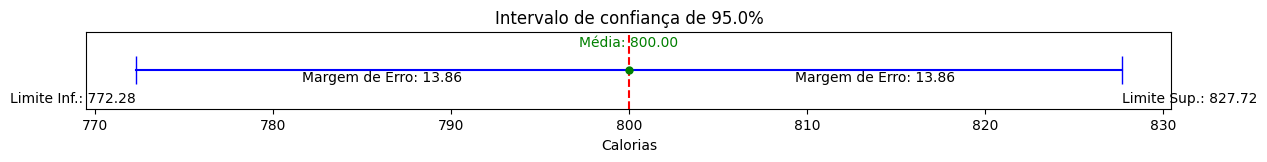

In [ ]:
#nº de calorias ingeridas ao almoço
n_dim = 50 #dimensão da amostra
nivel_confianca = 0.95 #Nível de confiança
media = 800 #média da amostra
desvio_padrao = 100#desvio padrão da amostra
var_estudo = "Calorias" #variável de estudo

Lim_inf_ex, Lim_sup_ex = intervalo_confianca(n_dim, nivel_confianca, media, desvio_padrao, var_estudo)
margem_ex = margem_erro(n_dim, nivel_confianca, media, desvio_padrao)
grafico(Lim_inf_ex, Lim_sup_ex, media, margem_ex, var_estudo, nivel_confianca)